# Proyecto de telecomunicaciones

### Introducción

El servicio de telefonía virtual CallMeMaybe busca mejorar la supervisión del desempeño de sus operadores mediante la identificación de aquellos que presentan bajos niveles de eficiencia. En este contexto, un operador se considera ineficaz si presenta una alta proporción de llamadas entrantes perdidas, tiempos de espera elevados y, en caso de realizar llamadas salientes, un volumen reducido de estas.

El objetivo de este proyecto es analizar los datos proporcionados sobre el uso del sistema de telefonía, con el fin de identificar patrones de comportamiento asociados a operadores ineficientes. Para ello, se llevará a cabo un análisis exploratorio de los datos (EDA), la construcción de métricas relevantes como la tasa de llamadas perdidas y el tiempo de espera, y la creación de un modelo de evaluación que permita clasificar a los operadores según su nivel de desempeño.

Adicionalmente, se aplicarán pruebas de hipótesis estadísticas para validar si las diferencias observadas entre operadores eficientes e ineficientes son estadísticamente significativas, lo que permitirá respaldar los hallazgos con evidencia cuantitativa.

Este análisis permitirá no solo identificar operadores con bajo rendimiento, sino también proporcionar información útil para la toma de decisiones orientadas a mejorar la eficiencia operativa del servicio.

### Empezamos a cargar las librerías a usar, y losDatasets

In [1]:
# Cargamos las liberrías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from scipy import stats

In [2]:
# cargamos el dataset

clients = pd.read_csv('telecom_clients.csv')

calls = pd.read_csv('telecom_dataset_new.csv')

## Exploración de los datos

In [3]:
# Revisamos las primeras filas del dataset, y su información general

print(clients.head(),
      clients.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB
   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901           A  2019-08-23
2   168527           A  2019-10-29
3   167097           A  2019-09-01
4   168193           A  2019-10-16 None


In [4]:
print(calls.head(),
      calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:00       out     

In [5]:
# Veremos si hay valores nulos en el dataset
calls.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [6]:
# Veremos si hay valores nulos en el dataset
clients.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

In [7]:
calls.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [8]:
calls['operator_id'].nunique()
calls['user_id'].nunique()

307

In [9]:
calls.groupby('direction')['calls_count'].sum()

direction
in     216863
out    669892
Name: calls_count, dtype: int64

In [10]:
calls.duplicated().sum()

np.int64(4900)

### Primeras observaciones

- En el conjunto de datos **calls**, el tipo de dato de la columna 'date' es object, deberíamos cambiarlo a tipo 'datetime'.
- En el conjunto de datos clients, el tipo de dato de la columna 'date_start' es object, lo cambiaremos a tipo 'datetime'.
- Vemos valores nulos en las columnas 'internal' y 'operator_id' del Dataset **calls**

### Limpieza de los datos

In [11]:
# convertir fechas

# convertimos la columna 'date' del Dataset calls a datetime
calls['date'] = pd.to_datetime(calls['date'])

# convertimos la columna 'date_start' del Dataset clients a datetime
clients['date_start'] = pd.to_datetime(clients['date_start'])

In [12]:
# Eliminamos los valores nulos del dataset calls

calls = calls.dropna(subset=['operator_id', 'internal'])

# verificamos que se hayan eliminado los valores nulos del dataset calls
calls.isna().sum()

user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
dtype: int64

### Cambios realizados
- Se corrigió la conversión de la columna 'date_start' del Dataset **clients** a datetime.
- Se eliminaron los valores nulos de las columnas 'internal' y 'operator_id' del Dataset **calls** porque no se puede analizar un operador si el dato es nulo.

## Operadores ineficaces

Ahora, que nuestros datos están limpios, podemos identificar qué operadores están siendo ineficaces, tomando en cuenta la cantidad de llamadas perdidas (internas y externas) y un el tiempo de espera para las llamadas entrantes. 

In [13]:
# Estadísticas descriptivas del dataset calls
calls.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,45670.000000,45670.000000,45670.000000,45670.000000,45670.000000
mean,167302.011408,916529.298796,16.925203,1010.934399,1323.697000
std,600.836406,21258.404689,59.081220,4017.101865,4735.336635
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,68.000000
50%,167175.000000,913938.000000,4.000000,107.000000,291.000000
75%,167827.000000,937708.000000,14.000000,774.000000,1112.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


Las estadísticas descriptivas muestran una alta variabilidad en la cantidad y duración de las llamadas, evidenciada por la gran diferencia entre los valores mínimos y máximos. Además, la mediana de llamadas es relativamente baja en comparación con el promedio, lo que sugiere la presencia de valores atípicos (outliers) que elevan la media.

### Llamadas internas vs externas

In [14]:
# Revisamos la cantidad de llamadas internas (entre el personal) vs llamadas externas (con clientes)
calls['internal'].value_counts()

internal
False    39861
True      5809
Name: count, dtype: int64

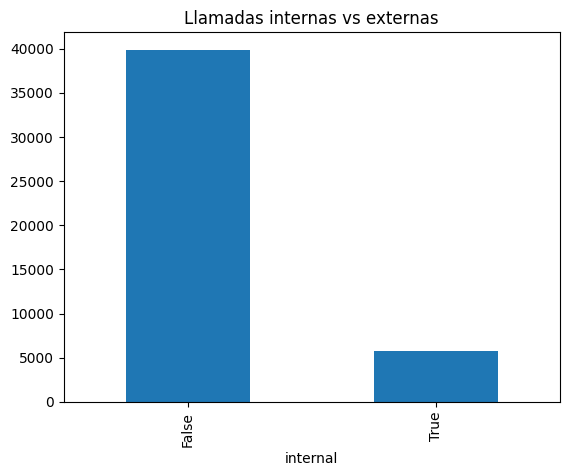

In [15]:
# Distribución de llamadas internas vs externas
calls['internal'].value_counts().plot(
    kind='bar', title='Llamadas internas vs externas')
plt.show()

### Análisis de llamadas internas vs externas

La mayoría de las llamadas son externas (aproximadamente 39,861), mientras que las llamadas internas representan una proporción mucho menor (alrededor de 5,809). Esto indica que el sistema se utiliza principalmente para la comunicación con clientes, lo cual es consistente con la naturaleza del servicio.

Las llamadas internas, aunque menos frecuentes, pueden ser relevantes para la coordinación entre operadores, pero no representan la mayor carga operativa.

### Llamadas entrantes vs salientes

In [16]:
# LLamadas entrantes vs llamadas salientes
calls['direction'].value_counts()

direction
out    31717
in     13953
Name: count, dtype: int64

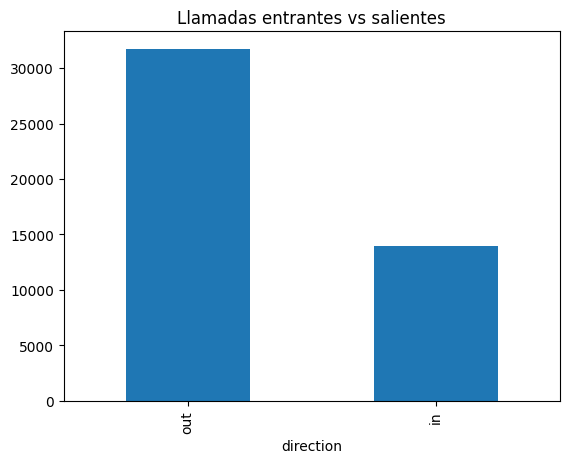

In [17]:
# Distribución de llamadas entrantes vs salientes
calls['direction'].value_counts().plot(
    kind='bar', title='Llamadas entrantes vs salientes')
plt.show()

### Análisis de llamadas entrantes vs salientes

La distribución de llamadas muestra que la mayoría son llamadas salientes (31,717), mientras que las llamadas entrantes representan una menor proporción (13,953). Esto indica que los operadores no solo atienden llamadas, sino que también realizan un volumen considerable de llamadas hacia los clientes.

Este comportamiento es relevante para el análisis de eficiencia, ya que un bajo número de llamadas salientes por operador podría ser un indicador de bajo desempeño en aquellos casos donde se espera actividad proactiva. Por lo tanto, esta variable será considerada en la evaluación de operadores ineficaces.

### Metricas de llamadas

Crearemos y analizaremos las métricas de las llamadas, esto será últil para identificar a los operadores ineficaces.

In [18]:
# Tiempo de espera
calls['wait_time'] = calls['total_call_duration'] - calls['call_duration']

In [19]:
# Crear wait_time
calls['wait_time'] = calls['total_call_duration'] - calls['call_duration']

# Agrupar
operator_stats = calls.groupby('operator_id').agg({
    'calls_count': 'sum',
    'is_missed_call': 'mean',
    'call_duration': 'mean',
    'wait_time': 'mean',
}).reset_index()

# Renombrar
operator_stats = operator_stats.rename(columns={
    'is_missed_call': 'missed_rate'
})

# Llamadas salientes
outgoing = calls[calls['direction'] == 'out']

outgoing_calls = outgoing.groupby(
    'operator_id')['calls_count'].sum().reset_index()
outgoing_calls = outgoing_calls.rename(
    columns={'calls_count': 'outgoing_calls'})

# Merge
operator_stats = operator_stats.merge(
    outgoing_calls, on='operator_id', how='left')

# Fill NA
operator_stats['outgoing_calls'] = operator_stats['outgoing_calls'].fillna(0)

### Criterios para identificar operadores ineficaces

- Tienen muchas llamadas perdidas.
- tienen un alto tiempo de espera.
- Tienen pocas llamadas salientes.

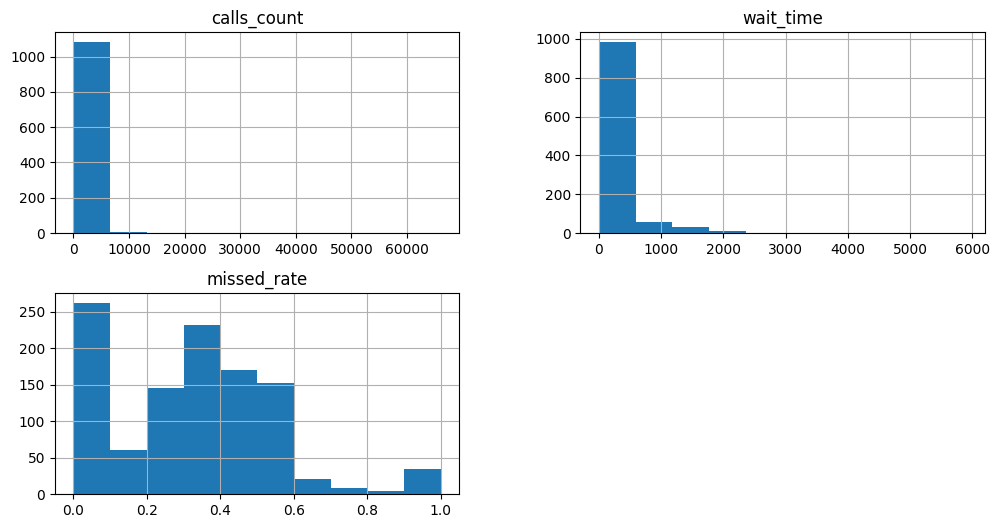

In [20]:
operator_stats[['calls_count', 'wait_time',
                'missed_rate']].hist(figsize=(12, 6))
plt.show()

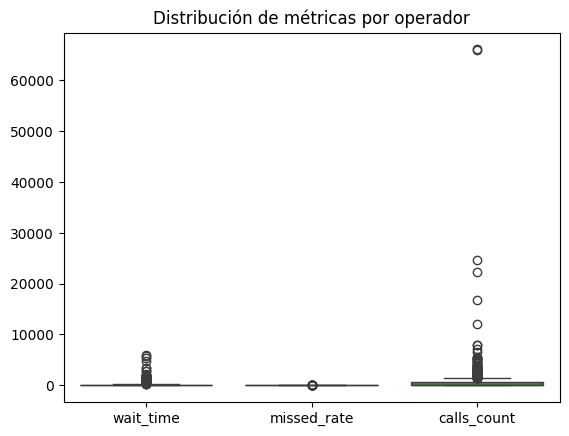

In [21]:

sns.boxplot(data=operator_stats[['wait_time', 'missed_rate', 'calls_count']])
plt.title('Distribución de métricas por operador')
plt.show()

# Creación de gráficos de cada métrico por operador

In [22]:
# Filtrar llamadas salientes y sumar el total por operador
outgoing_calls = calls[calls['direction'] == 'out'].groupby('operator_id')[
    'calls_count'].sum()

# Unir las llamadas salientes al dataset de métricas por operador
operator_stats = operator_stats.merge(
    outgoing_calls, on='operator_id', how='left')

# Crear columna de llamadas salientes y reemplazar valores nulos por 0
operator_stats['outgoing_calls'] = operator_stats['calls_count_y'].fillna(0)

# Eliminar columna duplicada generada por el merge
operator_stats.drop(columns=['calls_count_y'], inplace=True)

# Verificar columnas del dataset
print(operator_stats.columns)

# Renombrar columna original de llamadas totales
operator_stats.rename(columns={
    'calls_count_x': 'calls_count'
}, inplace=True)

Index(['operator_id', 'calls_count_x', 'missed_rate', 'call_duration',
       'wait_time', 'outgoing_calls'],
      dtype='object')


In [23]:
fig = go.Figure()

metrics = {
    'Total Calls': 'calls_count',
    'Missed Rate': 'missed_rate',
    'Wait Time': 'wait_time',
    'Call Duration': 'call_duration'
}

# Crear trazas
for i, (label, col) in enumerate(metrics.items()):
    fig.add_trace(
        go.Scatter(
            x=operator_stats['operator_id'],
            y=operator_stats[col],
            mode='markers',
            name=label,
            visible=(i == 0)  # solo el primero visible
        )
    )

# Crear dropdown
buttons = []
for i, (label, col) in enumerate(metrics.items()):
    visible = [False] * len(metrics)
    visible[i] = True

    buttons.append(
        dict(
            label=label,
            method='update',
            args=[
                {'visible': visible},
                {
                    'title': f'{label} por operador',
                    'yaxis': {'title': label}
                }
            ]
        )
    )

# Layout
fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.1,
            y=1.15
        )
    ],
    title='Total Calls por operador',
    xaxis_title='Operator ID',
    yaxis_title='Métrica',
    height=600
)

fig.show()

## Análisis de métricas por operador

Las distribuciones de las métricas muestran una alta variabilidad entre operadores, lo que sugiere diferencias importantes en su desempeño.

En el caso de `calls_count`, se observa una fuerte asimetría hacia la derecha, con algunos operadores manejando un volumen de llamadas considerablemente mayor que el resto, lo que indica la presencia de valores atípicos. Esto podría reflejar una distribución desigual de la carga de trabajo.

Para `wait_time`, la mayoría de los operadores presentan tiempos de espera bajos, pero existen algunos casos con valores significativamente altos, lo cual puede ser un indicio de ineficiencia en la gestión de llamadas.

La métrica `missed_rate` presenta una distribución más concentrada, aunque también se observan operadores con tasas elevadas de llamadas perdidas, lo cual es un factor crítico en la evaluación del desempeño.

El boxplot confirma la presencia de múltiples outliers en todas las métricas, especialmente en el número de llamadas y el tiempo de espera. Estos valores extremos son particularmente relevantes, ya que pueden corresponder a operadores altamente eficientes o, por el contrario, a operadores ineficientes que requieren atención.

En conjunto, estos resultados respaldan los criterios definidos para identificar operadores ineficaces, ya que evidencian la existencia de operadores con altos tiempos de espera, altas tasas de llamadas perdidas y comportamientos atípicos en el volumen de llamadas.

## Análisis de percentiles

En esta sección se calculan los percentiles 90, 95 y 99 para las métricas clave (`calls_count`, `missed_rate` y `wait_time`) con el objetivo de identificar valores extremos dentro de la distribución de los datos. 

Los percentiles permiten entender el comportamiento de los valores más altos, lo cual es especialmente útil para detectar operadores con desempeño atípico, ya sea por manejar un volumen excesivo de llamadas, presentar altos tiempos de espera o tener una elevada tasa de llamadas perdidas.

In [24]:
# Calcula los percentiles 90, 95 y 99 del número de llamadas por operador para identificar valores altos (outliers)
print(np.percentile(operator_stats['calls_count'], [90, 95, 99]))

[1790.5  2659.75 5456.8 ]


In [25]:
# Calcula los percentiles 90, 95 y 99 de la tasa de llamadas perdidas para detectar valores elevados
print(np.percentile(operator_stats['missed_rate'], [90, 95, 99]))

[0.54033264 0.66666667 1.        ]


In [26]:
# Calcula los percentiles 90, 95 y 99 del tiempo de espera para identificar valores extremos
print(np.percentile(operator_stats['wait_time'], [90, 95, 99]))

[ 546.65147059 1127.36605405 1935.69478006]


## Interpretación de resultados

Los resultados muestran que, en el percentil 90, algunos operadores ya presentan valores considerablemente altos en comparación con el resto, especialmente en el número de llamadas y el tiempo de espera. 

A partir del percentil 95 y, con mayor claridad en el percentil 99, se observan valores extremos, lo que confirma la presencia de outliers en las métricas analizadas. Por ejemplo, algunos operadores tienen tiempos de espera significativamente elevados y tasas de llamadas perdidas cercanas al máximo.

Estos hallazgos son importantes, ya que permiten establecer umbrales para identificar operadores potencialmente ineficientes. En particular, aquellos que se encuentran en los percentiles más altos de `wait_time` y `missed_rate`, o en los más bajos de actividad (calls_count), pueden ser considerados como candidatos a evaluación de desempeño.

## Construcción del score de ineficiencia

En esta sección se construyó un indicador compuesto (score) para evaluar la eficiencia de cada operador. Para ello, se aplicó una normalización Min-Max a las variables clave (`missed_rate`, `wait_time`, `calls_count` y `outgoing_calls`) con el fin de llevarlas a una misma escala entre 0 y 1.

Posteriormente, se asignaron pesos a cada métrica según su importancia en la identificación de ineficiencia: mayor peso a la tasa de llamadas perdidas y al tiempo de espera, y menor peso al volumen de llamadas y llamadas salientes (considerando que valores bajos en estas últimas indican menor desempeño).

Finalmente, se identificaron como operadores ineficientes aquellos que se encuentran en el percentil 95 del score, y se visualizó su comportamiento mediante un gráfico de dispersión.

In [ ]:
# Normaliza los valores de cada métrica en un rango de 0 a 1
def minmax(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-6)


# Calcula un score de ineficiencia dando mayor peso a missed_rate y wait_time
operator_stats['score'] = (
    # Mayor peso: llamadas perdidas
    minmax(operator_stats['missed_rate']) * 0.5 +
    # Alto peso: tiempo de espera
    minmax(operator_stats['wait_time']) * 0.4 +
    # Bajo peso: volumen de llamadas
    (1 - minmax(operator_stats['calls_count'])) * 0.05 +
    (1 - minmax(operator_stats['outgoing_calls'])) *
    0.05  # Bajo peso: llamadas salientes
)

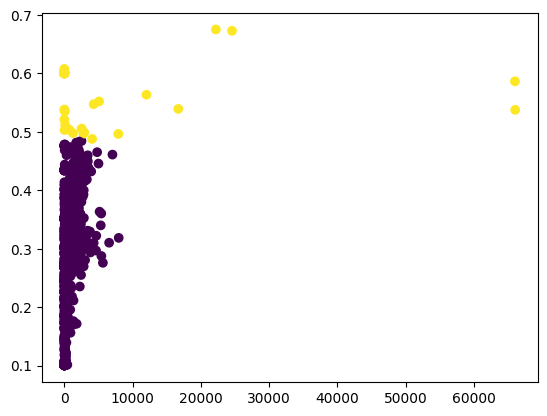

In [28]:
# Identifica el 5% de operadores más ineficientes y los resalta en el gráfico
colors = operator_stats['score'] > operator_stats['score'].quantile(0.95)

plt.scatter(
    operator_stats['calls_count'],
    operator_stats['score'],
    c=colors
)

plt.show()

## Análisis del score de ineficiencia

El gráfico muestra la relación entre el número de llamadas (`calls_count`) y el score de ineficiencia calculado para cada operador. Se observa que la mayoría de los operadores se concentran en niveles bajos de llamadas, con valores de ineficiencia moderados.

Los operadores resaltados (percentil 95 del score) representan el grupo más ineficiente. Estos tienden a presentar valores altos en el score, lo que indica una combinación de altos tiempos de espera y altas tasas de llamadas perdidas, factores que tienen mayor peso en el modelo.

Asimismo, se identifican algunos operadores con un alto volumen de llamadas pero con niveles de ineficiencia relativamente bajos, lo que sugiere un mejor desempeño operativo.

En general, el score permite distinguir claramente a los operadores con bajo rendimiento, validando los criterios definidos y facilitando su identificación para análisis o intervención futura.

In [29]:
operator_stats.sort_values(by='score', ascending=False).head(50)

,operator_id,calls_count,missed_rate,call_duration,wait_time,outgoing_calls,score
551,925922.0,22210,0.417722,11759.924051,5907.443038,21754.0,0.675287
583,929428.0,24572,0.500000,4194.285714,5325.342857,24572.0,0.673053
324,909308.0,15,1.000000,0.000000,116.333333,15.0,0.607854
617,932246.0,1,1.000000,0.000000,60.000000,1.0,0.604061
1041,962904.0,2,1.000000,0.000000,43.000000,2.0,0.602909
697,937770.0,1,1.000000,0.000000,37.000000,1.0,0.602504
666,936296.0,4,1.000000,0.000000,34.666667,4.0,0.602341
841,945074.0,3,1.000000,0.000000,26.000000,3.0,0.601756
160,899076.0,2,1.000000,0.000000,23.500000,2.0,0.601588
92,891976.0,2,1.000000,0.000000,23.000000,2.0,0.601555


## Pruebas de hipótesis

### Comparar operadores eficientes vs ineficientes

Hipótesis:
- H0 (nula):
No hay diferencia en el tiempo de espera entre operadores eficientes e ineficientes
- H1 (alternativa):
Los operadores ineficientes tienen mayor tiempo de espera

In [30]:
# Definir ineficientes (top 5%)
threshold = operator_stats['score'].quantile(0.95)

# Separar grupos
inefficient = operator_stats[operator_stats['score'] >= threshold]['wait_time']
efficient = operator_stats[operator_stats['score'] < threshold]['wait_time']

# Prueba t
t_stat, p_value = stats.ttest_ind(inefficient, efficient, equal_var=False)

print("p-value:", p_value)

p-value: 0.0016346867111482013


In [31]:
if p_value < 0.05:
    print("Rechazamos H0")
    print("Existe diferencia significativa")
    print("Los operadores ineficientes tienen mayor tiempo de espera")
else:
    print("No hay evidencia suficiente para rechazar H0")

Rechazamos H0
Existe diferencia significativa
Los operadores ineficientes tienen mayor tiempo de espera


## Hipótesis 2

### Relación entre llamadas perdidas y tiempo de espera
Hipótesis:
- H0: No hay relación entre missed_rate y wait_time
- H1: Sí hay relación

In [32]:
corr, p_value = stats.pearsonr(
    operator_stats['missed_rate'], operator_stats['wait_time'])

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.23698748227551483
p-value: 2.093170839392635e-15


In [33]:
if p_value < 0.05:
    print("Existe una relación estadísticamente significativa")

    if corr > 0:
        print(
            "Mientras mayor es el tiempo de espera, mayor es el número de llamadas perdidas")

    print("Esto respalda el modelo de ineficiencia")
else:
    print("No se encontró una relación estadísticamente significativa")

Existe una relación estadísticamente significativa
Mientras mayor es el tiempo de espera, mayor es el número de llamadas perdidas
Esto respalda el modelo de ineficiencia


## Hipótesis 3

### Llamadas realizadas vs eficiencia

- H0: El número de llamadas no afecta la eficiencia.
- H1: Menos llamadas = más ineficiencia.

In [34]:
# Nivel de significancia
alpha = 0.05

# Test estadístico
t_stat, p_value = stats.ttest_ind(
    inefficient_calls, efficient_calls, equal_var=False)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}\n")

# Decisión
if p_value < alpha:
    print("Rechazamos H0")
    print("Existe diferencia estadísticamente significativa en el número de llamadas")

    # Interpretación adicional según medias
    if inefficient_calls.mean() < efficient_calls.mean():
        print("Los operadores ineficientes realizan menos llamadas")
        print("Esto respalda la hipótesis de que menos llamadas = más ineficiencia")
    else:
        print(
            "Resultado inesperado: los operadores ineficientes no realizan menos llamadas")
else:
    print("No hay evidencia suficiente para rechazar H0")

NameError: name 'inefficient_calls' is not defined

# Conclusiones

